In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         KrishiRakshak — Agentic AI Demo Notebook               ║
# ║  ReAct-style agent: Image Diagnosis + RAG + Hindi/English TTS  ║
# ║  Run on Google Colab with T4 GPU                               ║
# ╚══════════════════════════════════════════════════════════════════╝

!pip install -q \
    transformers==4.44.2 \
    peft \
    torch torchvision \
    pillow \
    scikit-learn \
    boto3 \
    httpx \
    tqdm \
    pymupdf \
    faiss-cpu \
    cohere \
    lingua-language-detector \
    langchain-text-splitters

print("All packages installed")


All packages installed


In [2]:
import os
import json
import time
import io
import base64
import getpass
import textwrap
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import torch
import torchvision.transforms as T
from PIL import Image

import boto3
import httpx
import fitz                          # pymupdf — PDF extraction
import faiss
import numpy as np

from lingua import Language, LanguageDetectorBuilder
from langchain_text_splitters import RecursiveCharacterTextSplitter

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print("Imports OK")


PyTorch  : 2.10.0+cu128
CUDA     : True
Imports OK


In [3]:
import getpass

# AWS Credentials
os.environ["AWS_ACCESS_KEY_ID"]     = getpass.getpass("AWS Access Key ID: ")
os.environ["AWS_SECRET_ACCESS_KEY"] = getpass.getpass("AWS Secret Access Key: ")
os.environ["AWS_DEFAULT_REGION"]    = "ap-south-1"

# Sarvam API Key
SARVAM_API_KEY = getpass.getpass("Sarvam API Key: ")

# Endpoints & Models
SAGEMAKER_ENDPOINT = "bge-m3-krishirakshak"
BEDROCK_REGION      = "us-east-1"
COHERE_MODEL_ID     = "cohere.rerank-v3-5:0"

# Supported diseases (model was trained on these 5)
TOP_5_DISEASES = [
    "Corn Common Rust",
    "Tomato Leaf Mold",
    "Tomato Early Blight",
    "Tomato Late Blight",
    "Potato Late Blight",
]

# Language codes for Sarvam TTS
LANGUAGE_CODES = {
    "en": "en-IN",
    "hi": "hi-IN",
}

# Doc size threshold: below this → direct context, above → RAG
DIRECT_CONTEXT_TOKEN_LIMIT = 6000

print("Config ready")


AWS Access Key ID: ··········
AWS Secret Access Key: ··········
Sarvam API Key: ··········
Config ready


In [4]:
import torchvision.models as models
import torch.nn as nn

# ── Class order MUST match training (from TREATMENT_KB.keys()) ────────────────
TOP_5_DISEASES = [
    "Tomato Early Blight",   # index 0
    "Tomato Late Blight",    # index 1
    "Potato Late Blight",    # index 2
    "Tomato Leaf Mold",      # index 3
    "Corn Common Rust",      # index 4
]
NUM_CLASSES  = len(TOP_5_DISEASES)
IDX_TO_CLASS = {i: d for i, d in enumerate(TOP_5_DISEASES)}

# ── Architecture must match training exactly ──────────────────────────────────
def build_efficientnet(num_classes):
    model = models.efficientnet_b3(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

# ── Load from existing Colab path (no re-upload needed) ──────────────────────
import os
model_path = "/content/best_model.pth"

if not os.path.exists(model_path):
    print(f"File not found at {model_path}")
    print("Files in /content:", os.listdir("/content"))
else:
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    clf_model = build_efficientnet(NUM_CLASSES)
    clf_model.load_state_dict(torch.load(model_path, map_location=device))
    clf_model = clf_model.to(device)
    clf_model.eval()
    print(f"Model loaded from {model_path} on {device}")

# ── Preprocessing ─────────────────────────────────────────────────────────────
preprocess = T.Compose([
    T.Resize((300, 300)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def image_diagnosis_tool(image_path: str) -> dict:
    img    = Image.open(image_path).convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs     = torch.softmax(clf_model(tensor), dim=1)[0]
        conf, idx = probs.max(0)
    return {
        "tool"      : "image_diagnosis_tool",
        "disease"   : IDX_TO_CLASS[idx.item()],
        "confidence": round(conf.item() * 100, 1),
        "low_conf"  : conf.item() < 0.40,
    }

print("image_diagnosis_tool ready")


Model loaded from /content/best_model.pth on cuda
image_diagnosis_tool ready


In [5]:
import os, random
from pathlib import Path

# ── Setup Kaggle credentials ──────────────────────────────────────────────────
os.makedirs("/root/.kaggle", exist_ok=True)
kaggle_creds = {
    "username": getpass.getpass("Kaggle username: "),
    "key"     : getpass.getpass("Kaggle API key: ")
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# ── Download PlantVillage dataset ─────────────────────────────────────────────
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/data --unzip -q
print("Dataset downloaded")

# ── Pick 1 image per disease ──────────────────────────────────────────────────
image_root = Path("/content/data/plantvillage dataset/segmented")

DISEASE_FOLDER_MAP = {
    "Corn_(maize)___Common_rust_" : "Corn Common Rust",
    "Tomato___Leaf_Mold"          : "Tomato Leaf Mold",
    "Tomato___Early_blight"       : "Tomato Early Blight",
    "Tomato___Late_blight"        : "Tomato Late Blight",
    "Potato___Late_blight"        : "Potato Late Blight",
}

test_images = {}
for folder, disease in DISEASE_FOLDER_MAP.items():
    folder_path = image_root / folder
    imgs = list(folder_path.glob("*.jpg")) + list(folder_path.glob("*.JPG")) + list(folder_path.glob("*.png"))
    if imgs:
        test_images[disease] = str(random.choice(imgs))
        print(f"  {disease:30s} → {test_images[disease]}")

print(f"\nPicked {len(test_images)} images")


Kaggle username: ··········
Kaggle API key: ··········
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Dataset downloaded
  Corn Common Rust               → /content/data/plantvillage dataset/segmented/Corn_(maize)___Common_rust_/fae3d9dc-478c-48a0-bb03-58934cbdc568___RS_Rust 2048_final_masked.jpg
  Tomato Leaf Mold               → /content/data/plantvillage dataset/segmented/Tomato___Leaf_Mold/479d6746-71a9-4abc-83d7-8cbfcedf1496___Crnl_L.Mold 9150_final_masked.jpg
  Tomato Early Blight            → /content/data/plantvillage dataset/segmented/Tomato___Early_blight/a9a349e8-bf20-4495-8db5-70ca9293608d___RS_Erly.B 7367_final_masked.jpg
  Tomato Late Blight             → /content/data/plantvillage dataset/segmented/Tomato___Late_blight/16441ce5-dcfa-411c-8029-cef10b3f6474___GHLB2 Leaf 8687_final_masked.jpg
  Potato Late Blight             → /content/data/plantvillage dataset/segmented/Potato___Late_blight/eb2bd15b-a92b-4302-98

✅ True: Corn Common Rust          | Pred: Corn Common Rust          | Conf: 99.8%
✅ True: Tomato Leaf Mold          | Pred: Tomato Leaf Mold          | Conf: 100.0%
✅ True: Tomato Early Blight       | Pred: Tomato Early Blight       | Conf: 98.7%
✅ True: Tomato Late Blight        | Pred: Tomato Late Blight        | Conf: 94.6%
✅ True: Potato Late Blight        | Pred: Potato Late Blight        | Conf: 100.0%


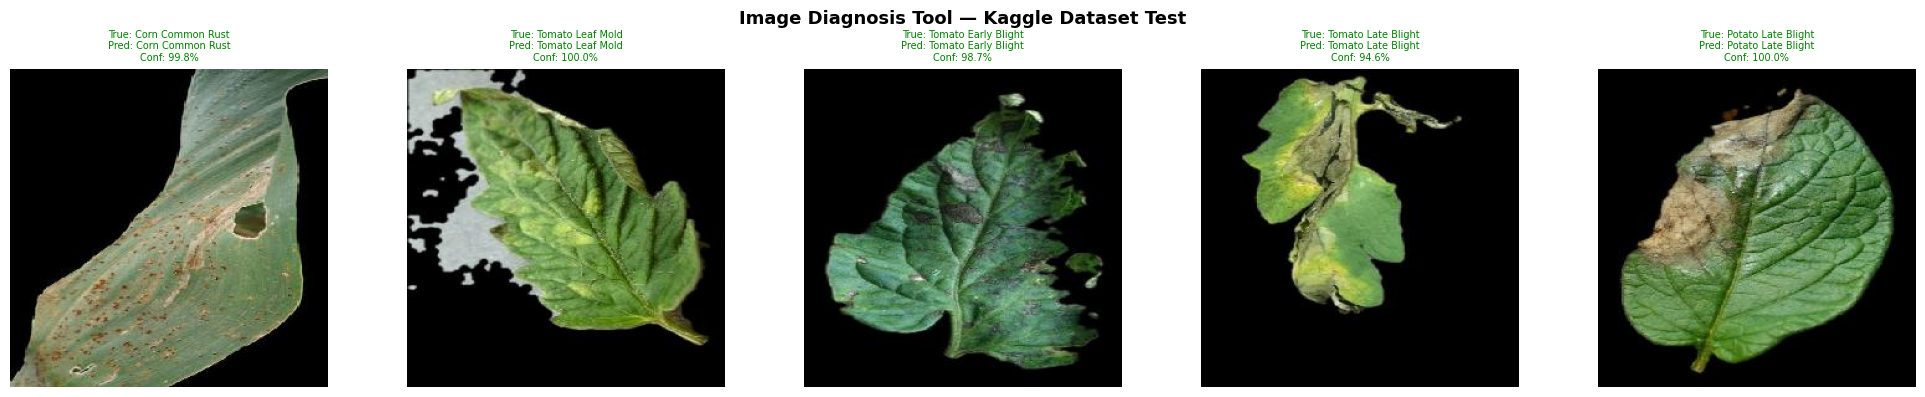

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results = {}
for true_label, path in test_images.items():
    result = image_diagnosis_tool(path)
    results[true_label] = result
    status = "✅" if result["disease"] == true_label else "❌"
    print(f"{status} True: {true_label:25s} | Pred: {result['disease']:25s} | Conf: {result['confidence']}%")

fig, axes = plt.subplots(1, len(test_images), figsize=(20, 4))
for ax, (true_label, path) in zip(axes, test_images.items()):
    r = results[true_label]
    correct = r["disease"] == true_label
    ax.imshow(mpimg.imread(path))
    ax.set_title(
        f"True: {true_label}\nPred: {r['disease']}\nConf: {r['confidence']}%",
        fontsize=7, color="green" if correct else "red"
    )
    ax.axis("off")

plt.suptitle("Image Diagnosis Tool — Kaggle Dataset Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [7]:
from lingua import Language, LanguageDetectorBuilder

detector = LanguageDetectorBuilder.from_languages(
    Language.ENGLISH,
    Language.HINDI,
).build()

def detect_language(text: str) -> str:
    lang = detector.detect_language_of(text)
    return "hi" if lang == Language.HINDI else "en"

# Test
print(detect_language("टमाटर की पत्तियों पर धब्बे हैं"))  # hi
print(detect_language("My tomato leaves have spots"))       # en
print("language_detection_tool ready")


hi
en
language_detection_tool ready


In [80]:
import re

DISEASE_LIST   = TOP_5_DISEASES
CROP_LIST      = ["Tomato", "Potato", "Corn"]
PESTICIDE_LIST = ["Mancozeb", "Ridomil Gold", "Metalaxyl", "Propiconazole",
                  "Chlorothalonil", "Indofil M-45", "Tilt 25 EC", "Kavach",
                  "Blitox", "Curzate", "Sectin", "Folicur"]
DISEASE_LIST    = TOP_5_DISEASES
CROP_LIST       = ["Tomato", "Potato", "Corn"]
PESTICIDE_LIST  = ["Mancozeb", "Ridomil Gold", "Metalaxyl", "Propiconazole",
                   "Chlorothalonil", "Indofil M-45", "Tilt 25 EC", "Kavach",
                   "Blitox", "Curzate", "Sectin", "Folicur"]

HINDI_MAP = {
    "टमाटर"        : ("crop",    "Tomato"),
    "आलू"          : ("crop",    "Potato"),
    "मक्का"        : ("crop",    "Corn"),
    "अर्ली ब्लाइट" : ("disease", "Tomato Early Blight"),
    "लेट ब्लाइट"   : ("disease", "Tomato Late Blight"),
    "लीफ मोल्ड"    : ("disease", "Tomato Leaf Mold"),
    "कॉमन रस्ट"    : ("disease", "Corn Common Rust"),
    "मैन्कोज़ेब"    : ("pesticide", "Mancozeb"),
    "प्रोपिकोनाज़ोल": ("pesticide", "Propiconazole"),
}

def extract_entities(text: str) -> dict:
    text_lower = text.lower()
    diseases   = [d for d in DISEASE_LIST   if d.lower() in text_lower]
    crops      = [c for c in CROP_LIST      if c.lower() in text_lower]
    pesticides = [p for p in PESTICIDE_LIST if p.lower() in text_lower]

    for hindi_word, (entity_type, english_name) in HINDI_MAP.items():
        if hindi_word in text:
            if entity_type == "crop"      and english_name not in crops:      crops.append(english_name)
            if entity_type == "disease"   and english_name not in diseases:   diseases.append(english_name)
            if entity_type == "pesticide" and english_name not in pesticides: pesticides.append(english_name)

    return {
        "disease_mentioned"  : diseases,
        "crop_mentioned"     : crops,
        "pesticide_mentioned": pesticides,
    }

# Test
print(extract_entities("टमाटर की फसल में अर्ली ब्लाइट रोग है मैन्कोज़ेब दवाई डालें"))
print(extract_entities("Apply Mancozeb for Tomato Early Blight every 7 days"))



{'disease_mentioned': ['Tomato Early Blight'], 'crop_mentioned': ['Tomato'], 'pesticide_mentioned': ['Mancozeb']}
{'disease_mentioned': ['Tomato Early Blight'], 'crop_mentioned': ['Tomato'], 'pesticide_mentioned': ['Mancozeb']}


In [8]:
eng_passage= '''Tomato, Potato, and Corn are important crops that are highly susceptible to various fungal diseases affecting yield and quality. One of the most common diseases in corn is Corn Common Rust, caused by the fungus Puccinia sorghi. It appears as reddish-brown pustules on leaves and spreads rapidly under humid conditions. Early detection and use of resistant hybrids are recommended to control the disease.

Tomato crops are vulnerable to multiple diseases including Tomato Leaf Mold, Tomato Early Blight, and Tomato Late Blight. Tomato Leaf Mold is caused by Passalora fulva and is characterized by yellow patches on the upper surface of leaves and mold growth underneath. It thrives in high humidity environments such as greenhouses.

Tomato Early Blight, caused by Alternaria solani, shows concentric ring patterns on older leaves, leading to defoliation. Crop rotation and fungicide application are common preventive measures. Tomato Late Blight, caused by Phytophthora infestans, is a severe disease that spreads quickly in cool and moist conditions. It leads to large water-soaked lesions and can destroy entire crops if not managed properly.

Potato Late Blight, also caused by Phytophthora infestans, is one of the most destructive diseases in potato farming. Symptoms include dark blotches on leaves and rapid decay of tubers. Farmers are advised to use certified seeds, maintain proper spacing, and apply fungicides as per agricultural advisories.

Government agricultural bodies such as ICAR recommend integrated pest management practices, timely monitoring, and the use of disease-resistant varieties to minimize crop losses.'''


hin_passage= '''टमाटर, आलू और मक्का भारत की महत्वपूर्ण फसलें हैं जो विभिन्न फफूंद जनित रोगों से प्रभावित होती हैं। मक्का में होने वाला एक प्रमुख रोग कॉर्न कॉमन रस्ट है, जो Puccinia sorghi नामक फफूंद के कारण होता है। यह पत्तियों पर लाल-भूरे धब्बों के रूप में दिखाई देता है और आर्द्र वातावरण में तेजी से फैलता है। इस रोग के नियंत्रण के लिए प्रतिरोधी किस्मों का उपयोग और समय पर निगरानी आवश्यक है।

टमाटर की फसल कई रोगों से प्रभावित होती है जैसे टमाटर लीफ मोल्ड, अर्ली ब्लाइट और लेट ब्लाइट। टमाटर लीफ मोल्ड Passalora fulva के कारण होता है और इसकी पहचान पत्तियों के ऊपरी हिस्से पर पीले धब्बों और नीचे फफूंद के विकास से होती है। यह अधिक आर्द्रता वाले वातावरण में तेजी से फैलता है।

टमाटर अर्ली ब्लाइट Alternaria solani के कारण होता है, जिसमें पत्तियों पर गोलाकार धब्बे दिखाई देते हैं। इससे पत्तियां सूख जाती हैं। इसके नियंत्रण के लिए फसल चक्र और फफूंदनाशक दवाओं का उपयोग किया जाता है। टमाटर लेट ब्लाइट Phytophthora infestans के कारण होता है और यह ठंडे तथा नम मौसम में तेजी से फैलता है। यह पूरी फसल को नष्ट कर सकता है।

आलू में लेट ब्लाइट एक गंभीर रोग है जो Phytophthora infestans के कारण होता है। इसके लक्षणों में पत्तियों पर काले धब्बे और कंदों का सड़ना शामिल है। किसानो को प्रमाणित बीज, उचित दूरी और समय पर दवा का उपयोग करना चाहिए।

भारतीय कृषि अनुसंधान परिषद (ICAR) किसानों को एकीकृत कीट प्रबंधन, नियमित निरीक्षण और उन्नत बीजों के उपयोग की सलाह देती है।'''

In [81]:
from datetime import date
import re

def chunk_text(text: str, source: str = "unknown", en_chunk_size=400, en_overlap=50, hi_min_chars=200) -> list:

    sentences = re.split(r'(?<=[।.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip()]
    tagged    = [(s, detect_language(s)) for s in sentences]

    groups = []
    cur_lang, cur_group = tagged[0][1], []
    for sent, lang in tagged:
        if lang == cur_lang:
            cur_group.append(sent)
        else:
            groups.append((cur_lang, cur_group))
            cur_lang, cur_group = lang, [sent]
    groups.append((cur_lang, cur_group))

    chunks      = []
    chunk_index = 0

    for lang, sents in groups:
        if lang == 'hi':
            current = ""
            for sent in sents:
                current += sent + " "
                if len(current) >= hi_min_chars:
                    entities = extract_entities(current)
                    chunks.append({"text": current.strip(), "source": source, "chunk_index": chunk_index, "language": "hi", "ingested_at": str(date.today()), **entities})
                    chunk_index  += 1
                    overlap_chars = int(len(current) * 0.2)
                    current       = current[-overlap_chars:].strip() + " "
            if current.strip():
                entities = extract_entities(current)
                if chunks and len(current.strip()) < hi_min_chars // 2:
                    chunks[-1]["text"] += " " + current.strip()
                else:
                    chunks.append({"text": current.strip(), "source": source, "chunk_index": chunk_index, "language": "hi", "ingested_at": str(date.today()), **entities})
                    chunk_index += 1
        else:
            splitter = RecursiveCharacterTextSplitter(chunk_size=en_chunk_size, chunk_overlap=en_overlap)
            for chunk in splitter.split_text(" ".join(sents)):
                entities = extract_entities(chunk)
                chunks.append({"text": chunk, "source": source, "chunk_index": chunk_index, "language": "en", "ingested_at": str(date.today()), **entities})
                chunk_index += 1

    return chunks



In [59]:
# Test
eng_chunks = chunk_text(eng_passage)
print(f"Total chunks: {len(eng_chunks)}\n")
for i, c in enumerate(eng_chunks):
    print(f"[{i}] ({len(c)} chars)\n{c}\n{'─'*60}")

Total chunks: 5

[0] (8 chars)
{'text': 'Tomato, Potato, and Corn are important crops that are highly susceptible to various fungal diseases affecting yield and quality. One of the most common diseases in corn is Corn Common Rust, caused by the fungus Puccinia sorghi. It appears as reddish-brown pustules on leaves and spreads rapidly under humid conditions. Early detection and use of resistant hybrids are recommended to control the', 'source': 'unknown', 'chunk_index': 0, 'language': 'en', 'ingested_at': '2026-04-13', 'disease_mentioned': ['Corn Common Rust'], 'crop_mentioned': ['Tomato', 'Potato', 'Corn'], 'pesticide_mentioned': []}
────────────────────────────────────────────────────────────
[1] (8 chars)
{'text': 'resistant hybrids are recommended to control the disease. Tomato crops are vulnerable to multiple diseases including Tomato Leaf Mold, Tomato Early Blight, and Tomato Late Blight. Tomato Leaf Mold is caused by Passalora fulva and is characterized by yellow patches on the u

In [82]:
# Test
hin_chunks = chunk_text(hin_passage)
print(f"Total chunks: {len(hin_chunks)}\n")
for i, c in enumerate(hin_chunks):
    print(f"[{i}] ({len(c)} chars)\n{c}\n{'─'*60}")


Total chunks: 7

[0] (8 chars)
{'text': 'टमाटर, आलू और मक्का भारत की महत्वपूर्ण फसलें हैं जो विभिन्न फफूंद जनित रोगों से प्रभावित होती हैं। मक्का में होने वाला एक प्रमुख रोग कॉर्न कॉमन रस्ट है, जो Puccinia sorghi नामक फफूंद के कारण होता है।', 'source': 'unknown', 'chunk_index': 0, 'language': 'hi', 'ingested_at': '2026-04-13', 'disease_mentioned': ['Corn Common Rust'], 'crop_mentioned': ['Tomato', 'Potato', 'Corn'], 'pesticide_mentioned': []}
────────────────────────────────────────────────────────────
[1] (8 chars)
{'text': 'inia sorghi नामक फफूंद के कारण होता है। यह पत्तियों पर लाल-भूरे धब्बों के रूप में दिखाई देता है और आर्द्र वातावरण में तेजी से फैलता है। इस रोग के नियंत्रण के लिए प्रतिरोधी किस्मों का उपयोग और समय पर निगरानी आवश्यक है।', 'source': 'unknown', 'chunk_index': 1, 'language': 'hi', 'ingested_at': '2026-04-13', 'disease_mentioned': [], 'crop_mentioned': [], 'pesticide_mentioned': []}
────────────────────────────────────────────────────────────
[2] (8 chars)
{'text': '्मो

In [12]:
import fitz  # pymupdf
import faiss
import numpy as np
from botocore.config import Config as BotoConfig

def get_embeddings(texts: list, prefix="passage") -> np.ndarray:
    runtime = boto3.client(
        "sagemaker-runtime", region_name="ap-south-1",
        config=BotoConfig(read_timeout=300, connect_timeout=60),
    )
    prefixed = [f"{prefix}: {t}" for t in texts]
    resp = runtime.invoke_endpoint(
        EndpointName=SAGEMAKER_ENDPOINT,
        ContentType="application/json",
        Body=json.dumps({"inputs": prefixed, "normalize": True}),
    )
    raw = json.loads(resp["Body"].read())
    return np.array(raw["embeddings"], dtype="float32")

def embed_chunks(chunks: list, batch_size=8) -> np.ndarray:
    all_vecs = []
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i:i+batch_size]
        vecs  = get_embeddings(batch, prefix="passage")
        all_vecs.append(vecs)
        print(f"  Batch {i//batch_size+1} done")
    result = np.vstack(all_vecs)
    print(f"Embedded {len(chunks)} chunks → shape: {result.shape}")
    return result


In [13]:
# Test
vecs_eng  = embed_chunks(eng_chunks)
print(vecs_eng)

  Batch 1 done
Embedded 5 chunks → shape: (5, 1024)
[[ 0.01935124  0.00239053 -0.01238886 ... -0.02402414 -0.03997609
  -0.00913398]
 [ 0.03680529 -0.01533069 -0.02006751 ... -0.02287648 -0.04344128
  -0.00245061]
 [ 0.04676432 -0.00614521 -0.03086132 ... -0.05477634 -0.03690704
  -0.02770902]
 [ 0.01979378  0.00711082 -0.02432317 ... -0.05200164 -0.02856747
  -0.00878367]
 [-0.01061051 -0.00987927 -0.01269005 ... -0.03707243 -0.03027929
   0.00048707]]


In [14]:
# Test
vecs_hin  = embed_chunks(hin_chunks)
print(vecs_hin)

  Batch 1 done
Embedded 7 chunks → shape: (7, 1024)
[[ 0.02685253  0.00781837 -0.02556365 ...  0.01525144 -0.04746058
  -0.02461472]
 [ 0.007065    0.0147122   0.00490553 ... -0.00306877 -0.03495817
   0.00070592]
 [ 0.00601856 -0.00664796 -0.03381372 ... -0.0185374  -0.02900887
  -0.01513052]
 ...
 [-0.00288361  0.00608127 -0.02821831 ... -0.01341945 -0.03292042
  -0.00831992]
 [ 0.00012089  0.02262277 -0.01836929 ... -0.02139433 -0.04300369
  -0.01235982]
 [-0.00264144 -0.0021547  -0.02922931 ... -0.03341349 -0.00928615
   0.00164988]]


In [15]:
Eng_query= '''What are the symptoms and control methods for Tomato Late Blight and how does it spread in crops?'''
Hin_query= '''टमाटर के लेट ब्लाइट रोग के लक्षण क्या हैं और इसके नियंत्रण के लिए किसान क्या उपाय कर सकते हैं?'''


In [18]:
faiss_index  = None
chunks       = []

def add_to_index(new_chunks: list):
    global faiss_index, chunks

    new_vecs = embed_chunks(new_chunks)

    if faiss_index is None:
        dim        = new_vecs.shape[1]
        faiss_index = faiss.IndexFlatIP(dim)

    faiss_index.add(new_vecs)
    chunks.extend(new_chunks)
    print(f"Added {len(new_chunks)} chunks. Total in index: {faiss_index.ntotal}")


In [19]:
add_to_index(eng_chunks)
add_to_index(hin_chunks)

  Batch 1 done
Embedded 5 chunks → shape: (5, 1024)
Added 5 chunks. Total in index: 5
  Batch 1 done
Embedded 7 chunks → shape: (7, 1024)
Added 7 chunks. Total in index: 12


In [20]:
# Build chunks from TREATMENT_KB (has all 5 diseases)
TREATMENT_KB = {
    "Tomato Early Blight" : "Tomato Early Blight. Caused by Alternaria solani. Symptoms: Brown spots with concentric rings on lower leaves. Treatment: Apply Mancozeb 75% WP (Indofil M-45) at 2.5g per litre every 7-10 days. Prevention: Crop rotation, avoid overhead irrigation.",
    "Tomato Late Blight"  : "Tomato Late Blight. Caused by Phytophthora infestans. Symptoms: Water-soaked grey-green spots, white mold underside. Treatment: Apply Metalaxyl + Mancozeb (Ridomil Gold) at 2g per litre every 5-7 days. Prevention: Use certified disease-free seeds.",
    "Potato Late Blight"  : "Potato Late Blight. Caused by Phytophthora infestans. Symptoms: Dark brown lesions on leaves and stems. Treatment: Apply Metalaxyl + Mancozeb (Ridomil Gold) at 2.5g per litre every 7 days. Prevention: Use certified seed potatoes.",
    "Tomato Leaf Mold"    : "Tomato Leaf Mold. Caused by Passalora fulva. Symptoms: Yellow patches on upper leaf surface, olive-green mold underside. Treatment: Apply Chlorothalonil (Kavach) at 2g per litre every 10 days. Prevention: Maintain humidity below 85%.",
    "Corn Common Rust"    : "Corn Common Rust. Caused by Puccinia sorghi. Symptoms: Brick-red to brown pustules on both leaf surfaces. Treatment: Apply Propiconazole (Tilt 25 EC) at 1ml per litre every 10-14 days. Prevention: Plant resistant hybrids.",
}

kb_chunks = list(TREATMENT_KB.values())
add_to_index(kb_chunks)

  Batch 1 done
Embedded 5 chunks → shape: (5, 1024)
Added 5 chunks. Total in index: 17


In [64]:
!pip install -q rank_bm25

In [83]:
from rank_bm25 import BM25Okapi
# Rebuild chunks with metadata
chunks = eng_chunks + hin_chunks
# Rebuild embeddings and indexes
texts       = [c["text"] for c in chunks]
vecs        = embed_chunks(texts)
dim         = vecs.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(vecs)
tokenized   = [c["text"].lower().split() for c in chunks]
bm25        = BM25Okapi(tokenized)

print(f"Rebuilt: {len(chunks)} chunks, {faiss_index.ntotal} vectors")

  Batch 1 done
  Batch 2 done
Embedded 12 chunks → shape: (12, 1024)
Rebuilt: 12 chunks, 12 vectors


In [84]:
def retriever_tool(query: str, k=5) -> list:

    # Step 1: Vector search
    q_vec            = get_embeddings([query], prefix="query")
    vec_scores, idxs = faiss_index.search(q_vec, k*2)
    vec_results      = {idxs[0][i]: i+1 for i in range(len(idxs[0])) if idxs[0][i] != -1}




    # Step 2: BM25
    bm25_scores  = bm25.get_scores(query.lower().split())
    bm25_ranked  = sorted(range(len(bm25_scores)), key=lambda i: bm25_scores[i], reverse=True)[:k*2]
    bm25_results = {bm25_ranked[i]: i+1 for i in range(len(bm25_ranked))}

    # Step 3: RRF
    all_ids = set(vec_results) | set(bm25_results)
    rrf     = {i: 1/(60+vec_results.get(i,k*2+1)) + 1/(60+bm25_results.get(i,k*2+1)) for i in all_ids}
    top_ids = sorted(rrf, key=lambda i: rrf[i], reverse=True)[:k]

    return [{"chunk": chunks[i]["text"], "metadata": chunks[i], "score": round(rrf[i], 4)} for i in top_ids]

# def retriever_tool(query: str, k=3) -> list:
#     q_vec = get_embeddings([query], prefix="query")
#     scores, indices = faiss_index.search(q_vec, k)
#     return [
#         {"chunk": chunks[i], "score": round(float(scores[0][j]), 4)}
#         for j, i in enumerate(indices[0]) if i != -1
#     ]

In [74]:
print(Eng_query)
retriever_tool(query= Eng_query)

What are the symptoms and control methods for Tomato Late Blight and how does it spread in crops?


[{'chunk': 'resistant hybrids are recommended to control the disease. Tomato crops are vulnerable to multiple diseases including Tomato Leaf Mold, Tomato Early Blight, and Tomato Late Blight. Tomato Leaf Mold is caused by Passalora fulva and is characterized by yellow patches on the upper surface of leaves and mold growth underneath. It thrives in high humidity environments such as greenhouses. Tomato Early',
  'metadata': {'text': 'resistant hybrids are recommended to control the disease. Tomato crops are vulnerable to multiple diseases including Tomato Leaf Mold, Tomato Early Blight, and Tomato Late Blight. Tomato Leaf Mold is caused by Passalora fulva and is characterized by yellow patches on the upper surface of leaves and mold growth underneath. It thrives in high humidity environments such as greenhouses. Tomato Early',
   'source': 'unknown',
   'chunk_index': 1,
   'language': 'en',
   'ingested_at': '2026-04-13',
   'disease_mentioned': ['Tomato Early Blight',
    'Tomato Late

In [85]:
print(Hin_query)
retriever_tool(query= Hin_query)

टमाटर के लेट ब्लाइट रोग के लक्षण क्या हैं और इसके नियंत्रण के लिए किसान क्या उपाय कर सकते हैं?


[{'chunk': 'त्तियों पर गोलाकार धब्बे दिखाई देते हैं। इससे पत्तियां सूख जाती हैं। इसके नियंत्रण के लिए फसल चक्र और फफूंदनाशक दवाओं का उपयोग किया जाता है। टमाटर लेट ब्लाइट Phytophthora infestans के कारण होता है और यह ठंडे तथा नम मौसम में तेजी से फैलता है।',
  'metadata': {'text': 'त्तियों पर गोलाकार धब्बे दिखाई देते हैं। इससे पत्तियां सूख जाती हैं। इसके नियंत्रण के लिए फसल चक्र और फफूंदनाशक दवाओं का उपयोग किया जाता है। टमाटर लेट ब्लाइट Phytophthora infestans के कारण होता है और यह ठंडे तथा नम मौसम में तेजी से फैलता है।',
   'source': 'unknown',
   'chunk_index': 4,
   'language': 'hi',
   'ingested_at': '2026-04-13',
   'disease_mentioned': ['Tomato Late Blight'],
   'crop_mentioned': ['Tomato'],
   'pesticide_mentioned': []},
  'score': 0.0323},
 {'chunk': 'है और यह ठंडे तथा नम मौसम में तेजी से फैलता है। यह पूरी फसल को नष्ट कर सकता है। आलू में लेट ब्लाइट एक गंभीर रोग है जो Phytophthora infestans के कारण होता है। इसके लक्षणों में पत्तियों पर काले धब्बे और कंदों का सड़ना शामिल है।',
  'met

In [29]:
def rag_generator(query: str, retrieved: list) -> str:
    context = "\n\n".join([f"[{i+1}] {r['chunk']}" for i, r in enumerate(retrieved)])
    lang    = detect_language(query)
    print(lang)

    system_prompt = """You are an agricultural expert helping Indian farmers.
RULES:
1. Respond in the SAME language as the query. if query is detected as Hindi query then Hindi answer.If English then answer in English
2. Plain prose only. No bullet points, no markdown, no asterisks.
3. Keep response under 150 words.
4. Mention at least one pesticide available in India with dosage.
5. End with one prevention tip.
6. Use only information from the provided context. Do not fabricate.
7. If exact information is not found then please say that not found in respective language."""

    user_message = f"Question: {query}\n\nContext:\n{context}"

    bedrock = boto3.client("bedrock-runtime", region_name="us-east-1")
    resp    = bedrock.invoke_model(
        modelId="us.anthropic.claude-sonnet-4-6",
        body=json.dumps({
            "anthropic_version": "bedrock-2023-05-31",
            "max_tokens"       : 300,
            "temperature"      : 0.1,
            "system"           : system_prompt,
            "messages"         : [{"role": "user", "content": user_message}],
        }),
    )
    return json.loads(resp["body"].read())["content"][0]["text"].strip()




In [27]:
# Test
print(f"\nQuery : {Eng_query}")
retrieved = retriever_tool(Eng_query, k=3)
answer    = rag_generator(Eng_query,retrieved)
print(f"Answer: {answer}\n{'─'*60}")


Query : What are the symptoms and control methods for Tomato Late Blight and how does it spread in crops?
en
Answer: Tomato Late Blight is caused by Phytophthora infestans. The main symptoms include water-soaked grey-green spots on leaves and a white mold growth on the underside of leaves. This disease spreads very quickly in cool and moist conditions, making it particularly dangerous during rainy or humid weather. The infection can move rapidly from plant to plant across the entire crop field, causing large water-soaked lesions that destroy the plant tissue.

For control, apply Metalaxyl plus Mancozeb, commonly available in India as Ridomil Gold, at a dosage of 2 grams per litre of water. Spray this every 5 to 7 days for effective management of the disease.

Prevention tip: Always use certified disease-free seeds before planting to reduce the initial source of infection in your tomato crop.
────────────────────────────────────────────────────────────


In [30]:
# Test
print(f"\nQuery : {Hin_query}")
retrieved = retriever_tool(Hin_query, k=3)
answer    = rag_generator(Hin_query,retrieved)
print(f"Answer: {answer}\n{'─'*60}")


Query : टमाटर के लेट ब्लाइट रोग के लक्षण क्या हैं और इसके नियंत्रण के लिए किसान क्या उपाय कर सकते हैं?
hi
Answer: टमाटर का लेट ब्लाइट रोग Phytophthora infestans नामक फफूंद के कारण होता है। यह रोग ठंडे और नम मौसम में तेजी से फैलता है और पूरी फसल को नष्ट कर सकता है। इसके लक्षणों में पत्तियों पर काले धब्बे दिखाई देते हैं और पत्तियां सूखने लगती हैं। यह रोग बहुत तेजी से एक पौधे से दूसरे पौधे में फैल सकता है।

इसके नियंत्रण के लिए किसान फसल चक्र अपनाएं और फफूंदनाशक दवाओं का उपयोग करें। Mancozeb 75 WP दवा को 2.5 ग्राम प्रति लीटर पानी में मिलाकर छिड़काव करें। यह दवा भारत में
────────────────────────────────────────────────────────────


In [42]:
def audio_generation_tool(text: str) -> str:
  """Generate Audios in place of answer generation. Use when retriever finds no relevant results."""
  polly  = boto3.client("polly", region_name="us-east-1")
  lang    = detect_language(text)
  voice  = "Aditi" if lang == "hi" else "Joanna"
  resp   = polly.synthesize_speech(
      Text         = text,
      OutputFormat = "mp3",
      VoiceId      = voice,
      Engine       = "standard",
  )
  audio_bytes = resp["AudioStream"].read()
  display(Audio(audio_bytes, autoplay=True))
  return "Audio generated successfully"


audio_generation_tool(answer)

'Audio generated successfully'

In [33]:
!pip install -q langgraph langchain-aws langchain-core


In [34]:
from langgraph.graph import StateGraph, END
from langchain_aws import ChatBedrockConverse
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage, SystemMessage
from typing import TypedDict, Annotated
import operator

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

llm = ChatBedrockConverse(
    model="us.anthropic.claude-sonnet-4-6",
    region_name="us-east-1",
    temperature=0.1,
)

print("State and LLM ready")


State and LLM ready


In [52]:
from langchain_core.tools import tool
from IPython.display import Audio, display

@tool
def image_diagnosis_tool_lc(image_path: str) -> str:
    """Diagnoses crop disease from a leaf image. Use when user provides an image path."""
    result = image_diagnosis_tool(image_path)
    if result["low_conf"]:
        return f"Low confidence ({result['confidence']}%). Advise farmer to consult Krishi Vigyan Kendra."
    return json.dumps(result)

@tool
def retriever_tool_lc(query: str) -> str:
    """Retrieves relevant crop disease information from knowledge base. Use for any text query about diseases."""
    results = retriever_tool(query, k=3)
    return json.dumps(results)

@tool
def web_search_tool_lc(query: str) -> str:
    """Search ICAR or government sources. Use when retriever finds no relevant results."""
    import urllib.parse, urllib.request, re
    q    = urllib.parse.quote(query + " crop disease site:icar.org.in OR site:agricoop.nic.in")
    url  = f"https://html.duckduckgo.com/html/?q={q}"
    req  = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    html = urllib.request.urlopen(req).read().decode("utf-8")
    snippets = re.findall(r'class="result__snippet">(.*?)</a>', html)
    return " ".join(snippets[:3]) if snippets else "No relevant results found."

@tool
def rag_generator_tool_lc(query: str, chunks_json: str) -> str:
    """Generates final answer from retrieved chunks in user's language."""
    chunks = json.loads(chunks_json)
    return rag_generator(query, chunks)


@tool
def audio_tool_lc(text: str) -> str:
    """Converts final response to audio. Always call this last. Language: 'en' or 'hi'."""
    audio_generation_tool(text)
    return "Audio generated"



tools = [
    image_diagnosis_tool_lc,
    retriever_tool_lc,
    web_search_tool_lc,
    rag_generator_tool_lc,
    audio_tool_lc,
]

llm_with_tools = llm.bind_tools(tools)
print(f"{len(tools)} tools bound to LLM")


5 tools bound to LLM


In [53]:
def agent_node(state: AgentState) -> AgentState:
    # LLM reasons about current state and decides next action
    response = llm_with_tools.invoke(state["messages"])

    # Print reasoning (Thought step)
    if response.content and not response.tool_calls:
        print(f"[Thought] {response.content}")

    if response.tool_calls:
        for call in response.tool_calls:
            print(f"[Action] Calling → {call['name']}")
            print(f"[Action] With args → {call['args']}")

    return {"messages": [response]}


def tool_node_react(state: AgentState) -> AgentState:
    last_msg  = state["messages"][-1]
    tool_msgs = []
    for call in last_msg.tool_calls:
        result = execute_tool_by_name(call["name"], call["args"])
        print(f"[Observation] {call['name']} returned → {str(result)[:150]}")
        # Observation fed back to LLM as ToolMessage
        tool_msgs.append(ToolMessage(
            content     = str(result),
            tool_call_id= call["id"]
        ))
    return {"messages": tool_msgs}

def should_continue(state: AgentState) -> str:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END


def execute_tool_by_name(name: str, args: dict) -> str:
    if name == "image_diagnosis_tool_lc":
        return image_diagnosis_tool_lc.invoke(args)
    elif name == "retriever_tool_lc":
        return retriever_tool_lc.invoke(args)
    elif name == "web_search_tool_lc":
        return web_search_tool_lc.invoke(args)
    elif name == "rag_generator_tool_lc":
        return rag_generator_tool_lc.invoke(args)
    elif name == "audio_tool_lc":
        return audio_tool_lc.invoke(args)
    return "Tool not found"

# Rebuild graph with ReAct nodes
graph = StateGraph(AgentState)
graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node_react)
graph.set_entry_point("agent")
graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph.add_edge("tools", "agent")
agent = graph.compile()

# System prompt forces explicit reasoning
SYSTEM = """You are KrishiRakshak, an AI assistant helping Indian farmers.

Follow this ReAct pattern strictly:
Thought: reason about what to do next based on user input and previous observations
Action: call the appropriate tool
Observation: analyze tool result
Thought: decide next step based on observation
... repeat until you have final answer then call audio_generation_tool

TOOL USAGE ORDER:
- Image input → image_diagnosis_tool → retriever_tool → rag_generator_tool → audio_tool
- Text query → retriever_tool → if poor results: web_search_tool → rag_generator_tool → audio_tool (Do not return audio unless user has asked for it)
- Text query -> No RAG required (LLM needs to call). switch to simple websearch tool
- Always respond in same language as user"""


def run_agent(user_input: str, file_path: str = None):
    content = user_input
    if file_path:
        content += f"\n[Uploaded file: {file_path}]"

    result = agent.invoke({
        "messages": [
            SystemMessage(content=SYSTEM),
            HumanMessage(content=content)
        ]
    })

    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for call in msg.tool_calls:
                print(f"[Action] → {call['name']}")

    return result["messages"][-1].content


In [54]:
# Test
print(run_agent("What pesticide should I use for Corn Common Rust? i would like to hear Audio"))

[Action] Calling → retriever_tool_lc
[Action] With args → {'query': 'pesticide for Corn Common Rust'}
[Observation] retriever_tool_lc returned → [{"chunk": "Corn Common Rust. Caused by Puccinia sorghi. Symptoms: Brick-red to brown pustules on both leaf surfaces. Treatment: Apply Propiconazole (
[Action] Calling → rag_generator_tool_lc
[Action] With args → {'query': 'What pesticide should I use for Corn Common Rust?', 'chunks_json': '[{"chunk": "Corn Common Rust. Caused by Puccinia sorghi. Symptoms: Brick-red to brown pustules on both leaf surfaces. Treatment: Apply Propiconazole (Tilt 25 EC) at 1ml per litre every 10-14 days. Prevention: Plant resistant hybrids.", "score": 0.8109}, {"chunk": "Tomato, Potato, and Corn are important crops that are highly susceptible to various fungal diseases affecting yield and quality. One of the most common diseases in corn is Corn Common Rust, caused by the fungus Puccinia sorghi. It appears as reddish-brown pustules on leaves and spreads rapidly und

[Observation] audio_tool_lc returned → Audio generated
[Thought] Here is the information about pesticides for **Corn Common Rust** 🌽:

---

### 🦠 Disease Overview
- **Disease:** Corn Common Rust
- **Caused by:** *Puccinia sorghi* (a fungus)
- **Symptoms:** Brick-red to brown pustules on **both surfaces** of leaves
- **Spreads rapidly** under humid conditions

---

### 💊 Recommended Pesticide (Fungicide)

| Detail | Information |
|---|---|
| **Chemical Name** | Propiconazole |
| **Brand Name** | Tilt 25 EC |
| **Dosage** | 1 ml per litre of water |
| **Spray Frequency** | Every **10–14 days** |
| **Application** | Spray on **both sides** of leaves |

---

### 🛡️ Prevention Tips
- 🌱 **Plant resistant hybrid varieties** of corn — the most effective long-term strategy.
- 👁️ **Monitor fields regularly**, especially during humid weather.
- Follow **ICAR's Integrated Pest Management (IPM)** practices for best results.

---

🔊 **Audio response has been generated for you!**
> ⚠️ *Always consult

In [55]:
from langgraph.checkpoint.memory import MemorySaver

# ── Memory store ──────────────────────────────────────────────────────────────
memory = MemorySaver()

# ── Compile graph WITH memory ─────────────────────────────────────────────────
agent = graph.compile(checkpointer=memory)
print("Agent compiled with memory")

# ── Runner with session ID ────────────────────────────────────────────────────
def run_agent(user_input: str, session_id: str = "default", file_path: str = None):
    content = user_input
    if file_path:
        content += f"\n[Uploaded file: {file_path}]"

    config = {"configurable": {"thread_id": session_id}}  # each farmer = unique session

    result = agent.invoke(
        {
            "messages": [
                SystemMessage(content=SYSTEM),
                HumanMessage(content=content)
            ]
        },
        config=config
    )

    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for call in msg.tool_calls:
                print(f"[Action] → {call['name']}")

    return result["messages"][-1].content

# ── Test multi-turn conversation ──────────────────────────────────────────────
session = "farmer_001"


Agent compiled with memory


In [56]:
print(run_agent("What pesticide should I use for Corn Common Rust? i would like to hear Audio"))

[Action] Calling → retriever_tool_lc
[Action] With args → {'query': 'pesticide for Corn Common Rust'}
[Observation] retriever_tool_lc returned → [{"chunk": "Corn Common Rust. Caused by Puccinia sorghi. Symptoms: Brick-red to brown pustules on both leaf surfaces. Treatment: Apply Propiconazole (
[Action] Calling → rag_generator_tool_lc
[Action] With args → {'query': 'What pesticide should I use for Corn Common Rust?', 'chunks_json': '[{"chunk": "Corn Common Rust. Caused by Puccinia sorghi. Symptoms: Brick-red to brown pustules on both leaf surfaces. Treatment: Apply Propiconazole (Tilt 25 EC) at 1ml per litre every 10-14 days. Prevention: Plant resistant hybrids.", "score": 0.8109}, {"chunk": "Tomato, Potato, and Corn are important crops that are highly susceptible to various fungal diseases affecting yield and quality. One of the most common diseases in corn is Corn Common Rust, caused by the fungus Puccinia sorghi. It appears as reddish-brown pustules on leaves and spreads rapidly und

[Observation] audio_tool_lc returned → Audio generated
[Thought] Here is the information about pesticides for **Corn Common Rust** 🌽:

---

### 🦠 Corn Common Rust
- **Caused by:** *Puccinia sorghi* (Fungus)
- **Symptoms:** Brick-red to brown pustules on **both surfaces** of leaves, spreads rapidly in humid conditions.

---

### 💊 Recommended Pesticide (Fungicide)

| Detail | Information |
|---|---|
| **Chemical Name** | Propiconazole |
| **Brand Name** | Tilt 25 EC |
| **Dosage** | 1 ml per litre of water |
| **Spray Frequency** | Every **10–14 days** |
| **Application** | Spray on **both sides** of leaves |

---

### 🛡️ Prevention Tips
- 🌱 Plant **resistant hybrid varieties** of corn for long-term protection.
- 👁️ Monitor fields regularly for **early detection**.
- Follow **ICAR's Integrated Pest Management (IPM)** practices to minimize crop losses.

---

🔊 **Audio has been generated** for the above response. Please listen to it for a convenient experience!

> ⚠️ *Always consult your 

In [ ]:
!pip install -q ragas datasets

In [92]:


from ragas import evaluate

from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
from ragas.embeddings import BaseRagasEmbeddings
from langchain_aws import ChatBedrockConverse
from datasets import Dataset
from typing import List

# ── BGE-M3 wrapper ────────────────────────────────────────────────────────────
from langchain_core.embeddings import Embeddings
from typing import List

class BGEM3Embeddings(Embeddings):
    def embed_query(self, text: str) -> List[float]:
        return get_embeddings([text], prefix="query")[0].tolist()

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return get_embeddings(texts, prefix="passage").tolist()



# ── Eval samples ──────────────────────────────────────────────────────────────
eval_samples = [
    {"query": "What pesticide should I use for Tomato Early Blight?",   "ground_truth": "Apply Mancozeb 75% WP at 2.5g per litre every 7-10 days",                      "language": "en"},
    {"query": "What causes Potato Late Blight?",                         "ground_truth": "Phytophthora infestans fungus causes Potato Late Blight",                       "language": "en"},
    {"query": "टमाटर लेट ब्लाइट के लिए कौन सी दवाई उपयोग करें?",      "ground_truth": "Ridomil Gold यानी Metalaxyl और Mancozeb का छिड़काव हर 5-7 दिन में करें",     "language": "hi"},
    {"query": "मक्का में कॉमन रस्ट के लक्षण क्या हैं?",                "ground_truth": "पत्तियों पर लाल-भूरे धब्बे दिखाई देते हैं",                                  "language": "hi"},
]

# ── Build dataset ─────────────────────────────────────────────────────────────
eval_data = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
for s in eval_samples:
    candidates = retriever_tool(s["query"], k=5)
    answer     = rag_generator(s["query"], candidates)
    eval_data["question"].append(s["query"])
    eval_data["answer"].append(answer)
    eval_data["contexts"].append([c["chunk"] for c in candidates])
    eval_data["ground_truth"].append(s["ground_truth"])

dataset = Dataset.from_dict(eval_data)



/tmp/ipykernel_69508/1852442420.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
/tmp/ipykernel_69508/1852442420.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
/tmp/ipykernel_69508/1852442420.py:3: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import faithfulness,

en
en
hi
hi


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[13]: ValidationException(An error occurred (ValidationException) when calling the Converse operation: The provided model identifier is invalid.)
ERROR:ragas.executor:Exception raised in Job[12]: ValidationException(An error occurred (ValidationException) when calling the Converse operation: The provided model identifier is invalid.)
ERROR:ragas.executor:Exception raised in Job[2]: ValidationException(An error occurred (ValidationException) when calling the Converse operation: The provided model identifier is invalid.)
ERROR:ragas.executor:Exception raised in Job[6]: ValidationException(An error occurred (ValidationException) when calling the Converse operation: The provided model identifier is invalid.)
ERROR:ragas.executor:Exception raised in Job[14]: ValidationException(An error occurred (ValidationException) when calling the Converse operation: The provided model identifier is invalid.)
ERROR:ragas.executor:Exception raised in Job[9]: Val

{'faithfulness': nan, 'answer_relevancy': nan, 'context_recall': nan, 'context_precision': nan}


In [93]:
# ── Run RAGAS ─────────────────────────────────────────────────────────────────
ragas_llm = ChatBedrockConverse(
    model      = "us.anthropic.claude-sonnet-4-6",
    region_name= "us-east-1"
)

scores = evaluate(
    dataset,
    metrics    = [faithfulness, answer_relevancy, context_recall, context_precision],
    llm        = ragas_llm,
    embeddings = BGEM3Embeddings(),
)

print(scores)


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

{'faithfulness': 0.4028, 'answer_relevancy': 0.6690, 'context_recall': 0.2500, 'context_precision': 0.2167}
